In [1]:
import cudf as cf
import cupy as cp

import optuna
# Use native XGBoost Dask API instead of dask-ml
import xgboost as xgb
# from dask_ml.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error        
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

from plotly.io import show

In [2]:
# Load the processed data
print("Loading csv data...")
df_dropped = cf.read_csv("./tmp/unfv_route_29_no_na_dropped.csv")
df_filled = cf.read_csv("./tmp/unfv_route_29_no_na_filled.csv")
print(f"Columns: {df_dropped.columns.tolist()}")

Loading csv data...
Columns: ['route', 'trip_id', 'stopid', 'hour', 'day_of_week', 'month', 'day_of_year', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'delay_seconds', 'Climate ID', 'Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)', 'bound', 'thrusteet_Dufferin St', 'thrusteet_Manitoba Dr', 'thrusteet_Nova Scotia Ave', 'thrusteet_Princes Blvd', "thrusteet_Princes' Blvd", "thrusteet_Princes' Gates Loop", 'thrusteet_Saskatchewan Rd', 'thrusteet_Wilson Ave', 'thrusteet_Wilson Station']


In [3]:
df_dropped.dtypes

route                            float64
trip_id                            int64
stopid                             int64
hour                             float64
day_of_week                      float64
month                            float64
day_of_year                      float64
hour_sin                         float64
hour_cos                         float64
day_of_week_sin                  float64
day_of_week_cos                  float64
delay_seconds                    float64
Climate ID                       float64
Temp (°C)                        float64
Dew Point Temp (°C)              float64
Rel Hum (%)                      float64
Wind Spd (km/h)                  float64
Visibility (km)                  float64
Stn Press (kPa)                  float64
bound                              int64
thrusteet_Dufferin St              int64
thrusteet_Manitoba Dr              int64
thrusteet_Nova Scotia Ave          int64
thrusteet_Princes Blvd             int64
thrusteet_Prince

In [4]:
df_dropped.isna().sum()

route                            0
trip_id                          0
stopid                           0
hour                             0
day_of_week                      0
month                            0
day_of_year                      0
hour_sin                         0
hour_cos                         0
day_of_week_sin                  0
day_of_week_cos                  0
delay_seconds                    0
Climate ID                       0
Temp (°C)                        0
Dew Point Temp (°C)              0
Rel Hum (%)                      0
Wind Spd (km/h)                  0
Visibility (km)                  0
Stn Press (kPa)                  0
bound                            0
thrusteet_Dufferin St            0
thrusteet_Manitoba Dr            0
thrusteet_Nova Scotia Ave        0
thrusteet_Princes Blvd           0
thrusteet_Princes' Blvd          0
thrusteet_Princes' Gates Loop    0
thrusteet_Saskatchewan Rd        0
thrusteet_Wilson Ave             0
thrusteet_Wilson Sta

In [5]:
df_dropped['delay_seconds'].describe()

count    4.851443e+06
mean     3.508565e+01
std      7.771582e+02
min     -2.152100e+04
25%     -2.270000e+02
50%     -5.400000e+01
75%      1.448015e+02
max      3.779996e+04
Name: delay_seconds, dtype: float64

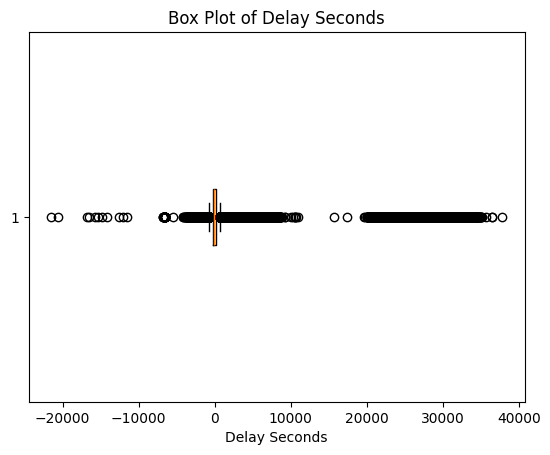

In [6]:
import matplotlib.pyplot as plt
plt.boxplot(df_dropped['delay_seconds'].to_pandas(), vert=False)
plt.title('Box Plot of Delay Seconds')
plt.xlabel('Delay Seconds')
plt.show()

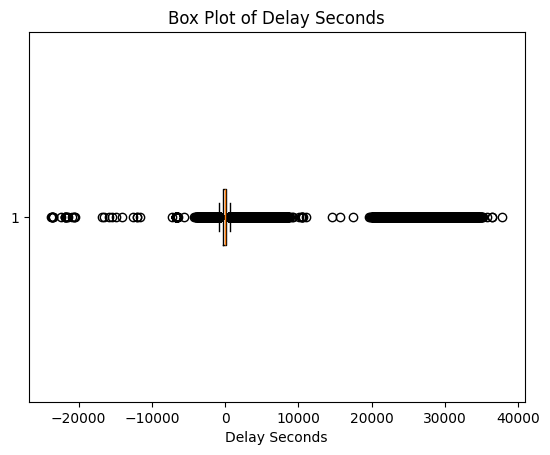

In [7]:
plt.boxplot(df_filled['delay_seconds'].to_pandas(), vert=False)
plt.title('Box Plot of Delay Seconds')
plt.xlabel('Delay Seconds')
plt.show()

In [8]:
print(f"\nFeature shape(Filled): {df_filled.shape[0]:,} rows x {df_filled.shape[1]} columns")


Feature shape(Filled): 5,025,282 rows x 30 columns


In [9]:
print(f"\nFeature shape(Dropped): {df_dropped.shape[0]:,} rows x {df_dropped.shape[1]} columns")


Feature shape(Dropped): 4,851,443 rows x 29 columns


## Dropped 

In [10]:
cp.get_default_memory_pool().free_all_blocks()

In [11]:
X_train_dropped, X_test_dropped, y_train_dropped, y_test_dropped = train_test_split(
    df_dropped.drop(columns=['delay_seconds', 'trip_id']),
    df_dropped['delay_seconds'],
    test_size=0.2,
    random_state=42
)

print(f"\nTrain size: {len(X_train_dropped):,}")
print(f"Test size: {len(X_test_dropped):,}")


Train size: 3,881,154
Test size: 970,289


In [12]:
X_train_dropped = X_train_dropped.to_cupy()
y_train_dropped = y_train_dropped.to_cupy()
X_test_dropped = X_test_dropped.to_cupy()
y_test_dropped = y_test_dropped.to_cupy()

In [59]:
# # Define Optuna objective function for hyperparameter tuning
import numpy as np
def objective(trial):
    """Optuna objective function to minimize RMSE using native XGBoost Dask API"""
    
    # Define hyperparameter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cuda',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 10_000,20_000, step=1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    
    n_samples = X_train_dropped.shape[0]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    avg_r2_squares = np.zeros(kf.get_n_splits())
    
    # KFold.split only needs sample count — pass a range, no GPU→CPU data transfer
    for i, (train_index, val_index) in enumerate(kf.split(range(n_samples))):
        # Index cupy arrays directly with numpy indices
        dtrain = xgb.QuantileDMatrix(X_train_dropped[train_index], label=y_train_dropped[train_index])
        dval = xgb.QuantileDMatrix(X_train_dropped[val_index], label=y_train_dropped[val_index], ref=dtrain)

        model = xgb.train(params, dtrain, evals=[(dval, 'eval')], 
                      verbose_eval=False, early_stopping_rounds=100)
    
        # Make predictions (returns numpy array)
        y_pred = model.predict(dval)
    
        # Convert only the fold's labels to numpy for R2 score calculation
        y_fold = y_train_dropped[val_index].get()
        r2_square = r2_score(y_fold, y_pred)
        avg_r2_squares[i] = r2_square

    # Return average R2 square across folds
    return float(np.mean(avg_r2_squares))

print("Objective function defined with native XGBoost and Optuna GPU")

Objective function defined with native XGBoost and Optuna GPU


In [60]:
# import numpy as np
# def objective(trial):
#     """Optuna objective function to minimize RMSE using native XGBoost Dask API"""
    
#     # Define hyperparameter search space
#     params = {
#         'objective': 'reg:squarederror',
#         'tree_method': 'hist',
#         'device': 'cuda',
#         # Use max_leaves instead of or alongside max_depth for more flexible trees
#         'max_leaves': trial.suggest_int('max_leaves', 31, 512),
#         'grow_policy': 'lossguide',  # Required for max_leaves to work with hist
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
#         'n_estimators': trial.suggest_int('n_estimators', 10_000,15_000, step=1000),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         # L2 regularization on leaf weights (default=1)
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),

#         # L1 regularization on leaf weights (default=0)
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),

#         # Minimum loss reduction for further partitioning (default=0)
#         'gamma': trial.suggest_float('gamma', 0, 5.0),

#         # Minimum child weight — prevents overfitting to small leaf nodes
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
#         'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
#         'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0),
        
#     }
    
#     n_samples = X_train_dropped.shape[0]
#     kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
#     avg_r2_scores = np.zeros(kf.get_n_splits())
    
#     # KFold.split only needs sample count — pass a range, no GPU→CPU data transfer
#     for i, (train_index, val_index) in enumerate(kf.split(range(n_samples))):
#         # Index cupy arrays directly with numpy indices
#         dtrain = xgb.QuantileDMatrix(X_train_dropped[train_index], label=y_train_dropped[train_index])
#         dval = xgb.QuantileDMatrix(X_train_dropped[val_index], label=y_train_dropped[val_index], ref=dtrain)

#         model = xgb.train(params, dtrain, evals=[(dval, 'eval')], 
#                       verbose_eval=False, early_stopping_rounds=100)
    
#         # Make predictions (returns numpy array)
#         y_pred = model.predict(dval)
    
#         # Convert only the fold's labels to numpy for RMSE calculation
#         y_fold = y_train_dropped[val_index].get()
#         r2_scores = r2_score(y_fold, y_pred)
#         avg_r2_scores[i] = r2_scores

#         trial.report(np.mean(avg_r2_scores), i)
#         if trial.should_prune():
#             raise optuna.TrialPruned()
        
#     # Return average R2 across folds
#     return float(np.mean(avg_r2_scores))

# print("Objective function defined with native XGBoost and Optuna GPU")

In [61]:
# Run Optuna hyperparameter optimization
print("Starting Optuna hyperparameter optimization...")
print("XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.")
print("This may take a while...\n")



# Create study with DaskStorage
study = optuna.create_study(
    direction='maximize',  # Maximize R2 square
    study_name='xgboost_delay_prediction',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Run optimization sequentially (XGBoost Dask handles parallelization internally)
n_trials = 50  # Total number of trials

print(f"Running {n_trials} trials...")

# Run sequential optimization - each trial uses Dask cluster efficiently
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest trial: #{study.best_trial.number}")
print(f"Best RMSE: {study.best_value:.4f}")
print("\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-04 22:06:17,283] A new study created in memory with name: xgboost_delay_prediction


Starting Optuna hyperparameter optimization...
XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.
This may take a while...

Running 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:06:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:06:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:06:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:06:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-04 22:06:18,985] Trial 0 finished with value: 0.5332634761470715 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 18000, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746}. Best is trial 0 with value: 0.5332634761470715.


...

[I 2026-03-04 22:07:59,687] Trial 47 finished with value: 0.7065247732455208 and parameters: {'max_depth': 10, 'learning_rate': 0.1597709226994552, 'n_estimators': 15000, 'subsample': 0.8363936125950272, 'colsample_bytree': 0.7985798079997067}. Best is trial 45 with value: 0.7455988668143938.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:07:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:08:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:08:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:08:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-04 22:08:01,751] Trial 48 finished with value: 0.2566110583295396 and parameters: {'max_depth': 9, 'learning_rate': 0.02285418468349135, 'n_estimators': 16000, 'subsample': 0.8159831861430643, 'colsample_bytree': 0.8962579848760861}. Best is trial 45 with value: 0.7455988668143938.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:08:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:08:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:08:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:08:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-04 22:08:03,096] Trial 49 finished with value: 0.06839315541014848 and parameters: {'max_depth': 3, 'learning_rate': 0.12112411090301071, 'n_estimators': 15000, 'subsample': 0.6612071907870587, 'colsample_bytree': 0.8470827526158865}. Best is trial 45 with value: 0.7455988668143938.

OPTIMIZATION COMPLETE!

Best trial: #45
Best RMSE: 0.7456

Best hyperparameters:
  max_depth: 10
  learning_rate: 0.2956728466248031
  n_estimators: 15000
  subsample: 0.8381460257316069
  colsample_bytree: 0.8411709146033937


In [62]:
fig = optuna.visualization.plot_param_importances(study)
show(fig)

In [63]:
study.best_params

{'max_depth': 10,
 'learning_rate': 0.2956728466248031,
 'n_estimators': 15000,
 'subsample': 0.8381460257316069,
 'colsample_bytree': 0.8411709146033937}

In [64]:
cp.get_default_memory_pool().free_all_blocks()

In [65]:
# Train final model with best parameters using native XGBoost Dask API
print("Training final model with best hyperparameters...")
print("="*60)

# Get best parameters
best_params = study.best_params.copy()
best_params_clean = {k: v for k, v in best_params.items() if k != 'num_boost_round'}
best_params['objective'] = 'reg:squarederror'
best_params['tree_method'] = 'hist'  # Required for Dask

# Create QuantileDMatrix for training
dtrain = xgb.DMatrix(X_train_dropped, y_train_dropped)

# Train final model using native Dask XGBoost
output = xgb.train(
    best_params,
    dtrain,
)

Training final model with best hyperparameters...


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning:

[22:08:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




In [66]:
dtest = xgb.DMatrix(X_test_dropped)
y_pred_dropped = output.predict(dtest)

In [67]:
rmse = np.sqrt(mean_squared_error(y_test_dropped.get(), y_pred_dropped))
r2 = r2_score(y_test_dropped.get(), y_pred_dropped)
print("Final Model Performance on Test Set:")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²: {r2:.4f}")

Final Model Performance on Test Set:
  RMSE: 393.6201
  R²: 0.7417


In [21]:
output.set_param({'device': 'cuda'})

In [22]:
import shap
shap_values = output.predict(dtrain, pred_contribs=True)

In [23]:
output

In [24]:
explainer = shap.TreeExplainer(output)

In [25]:
shap_values = explainer.shap_values(X_test_dropped)

In [26]:
feature_names = df_dropped.drop(columns=['delay_seconds', 'trip_id']).columns.tolist()

In [27]:
shap_values

array([[ 0.0000000e+00,  4.1083633e+01, -1.6570045e+01, ...,
         6.4431550e-03,  3.0003962e-04,  3.3304818e-02],
       [ 0.0000000e+00, -3.4096577e+01, -6.1858130e+00, ...,
        -1.6815690e-02,  3.1459643e-04,  2.1049608e-02],
       [ 0.0000000e+00, -3.9263004e+01, -1.6947954e+01, ...,
        -8.9995172e-03,  3.0233455e-04,  2.5868118e-02],
       ...,
       [ 0.0000000e+00, -1.2320531e+01, -2.2618780e+01, ...,
        -1.4214656e-02,  5.6064193e-04,  3.8510028e-02],
       [ 0.0000000e+00, -2.3912872e+01, -1.0538655e+01, ...,
        -4.9156724e-03,  3.1872498e-04,  2.2410003e-02],
       [ 0.0000000e+00, -7.9080954e+00, -4.5347885e+01, ...,
        -1.7425004e-02,  5.2381662e-04,  2.8562307e-02]],
      shape=(970289, 27), dtype=float32)

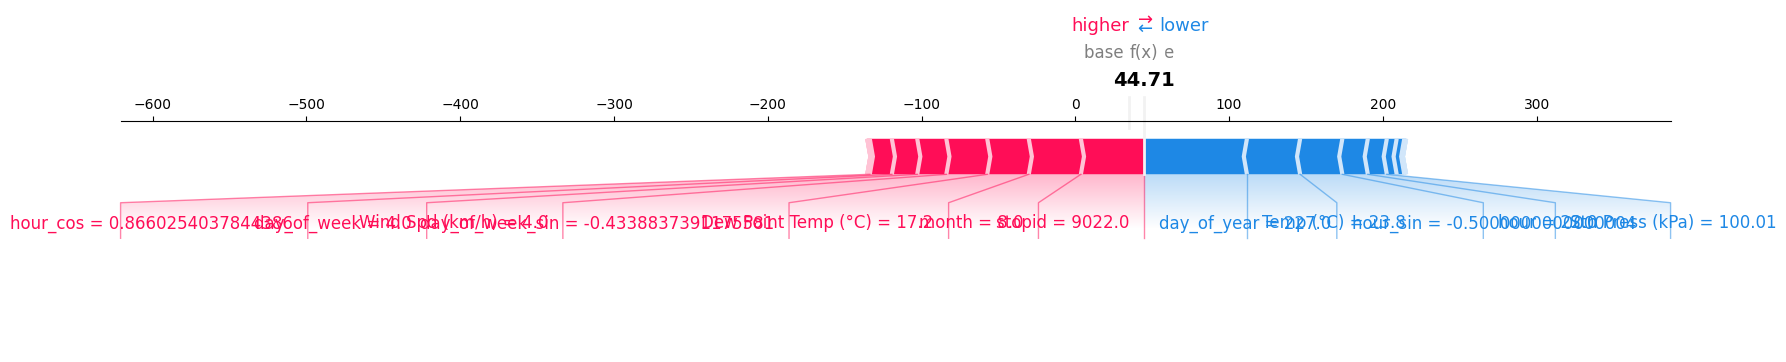

In [28]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_train_dropped[0, :].get(),
    feature_names=feature_names,
    matplotlib=True,
)

## Filled

In [29]:
cp.get_default_memory_pool().free_all_blocks()

In [30]:
X_train_filled, X_test_filled, y_train_filled, y_test_filled = train_test_split(
    df_filled.drop(columns=['delay_seconds', 'trip_id',]),
    df_filled['delay_seconds'],
    test_size=0.2,
    random_state=42
)

In [31]:
X_train_filled = X_train_filled.to_cupy()
y_train_filled = y_train_filled.to_cupy()
X_test_filled = X_test_filled.to_cupy()
y_test_filled = y_test_filled.to_cupy()

In [34]:
# Define Optuna objective function for hyperparameter tuning
def objective(trial):
    """Optuna objective function to minimize RMSE using native XGBoost Dask API"""
    
    # Define hyperparameter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cuda',
        # Use max_leaves instead of or alongside max_depth for more flexible trees
        'max_leaves': trial.suggest_int('max_leaves', 31, 512),
        'grow_policy': 'lossguide',  # Required for max_leaves to work with hist
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 10_000,15_000, step=1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        # L2 regularization on leaf weights (default=1)
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),

        # L1 regularization on leaf weights (default=0)
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),

        # Minimum loss reduction for further partitioning (default=0)
        'gamma': trial.suggest_float('gamma', 0, 5.0),

        # Minimum child weight — prevents overfitting to small leaf nodes
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0),
        
    }
    
    n_samples = X_train_filled.shape[0]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
    avg_r2_scores = np.zeros(kf.get_n_splits())
    
    # KFold.split only needs sample count — pass a range, no GPU→CPU data transfer
    for i, (train_index, val_index) in enumerate(kf.split(range(n_samples))):
        # Index cupy arrays directly with numpy indices
        dtrain = xgb.QuantileDMatrix(X_train_filled[train_index], label=y_train_filled[train_index])
        dval = xgb.QuantileDMatrix(X_train_filled[val_index], label=y_train_filled[val_index], ref=dtrain)

        model = xgb.train(params, dtrain, evals=[(dval, 'eval')], 
                      verbose_eval=False, early_stopping_rounds=100)
    
        # Make predictions (returns numpy array)
        y_pred = model.predict(dval)
    
        # Convert only the fold's labels to numpy for RMSE calculation
        y_fold = y_train_filled[val_index].get()
        r2_scores = r2_score(y_fold, y_pred)
        avg_r2_scores[i] = r2_scores

        trial.report(np.mean(avg_r2_scores), i)
        if trial.should_prune():
            raise optuna.TrialPruned()
        
    # Return average R2 across folds
    return float(np.mean(avg_r2_scores))

print("Objective function defined with native XGBoost and Optuna GPU")

Objective function defined with native XGBoost and Optuna GPU


In [35]:
# Run Optuna hyperparameter optimization
print("Starting Optuna hyperparameter optimization...")
print("XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.")
print("This may take a while...\n")


# Create study with DaskStorage
study = optuna.create_study(
    direction='maximize',  # Maximize R2
    study_name='xgboost_delay_prediction',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Run optimization sequentially (XGBoost Dask handles parallelization internally)
n_trials = 30  # Total number of trials

print(f"Running {n_trials} trials...")

# Run sequential optimization - each trial uses Dask cluster efficiently
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest trial: #{study.best_trial.number}")
print(f"Best RMSE: {study.best_value:.4f}")
print("\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-04 21:58:47,296] A new study created in memory with name: xgboost_delay_prediction


Starting Optuna hyperparameter optimization...
XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.
This may take a while...

Running 30 trials...


  0%|          | 0/30 [00:00<?, ?it/s]

/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[21:58:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[21:58:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[21:58:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[21:58:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-04 21:58:50,000] Trial 0 finished with value: 0.5285622221359156 and parameters: {'max_leaves': 211, 'learning_rate': 0.24517932047070642, 'n_estimators': 14000, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_lambda': 0.004207053950287938, 'reg_alpha': 0.0017073967431528124, 'gamma': 4.330880728874676, 'min_child_weight': 31, 'colsample_bylevel': 0.8540362888980227, 'colsample_bynode': 0.5102922471479012}. Best is trial 0 with value: 0.5285622221359156.


...

[I 2026-03-04 21:59:35,060] Trial 27 finished with value: 0.6011400933528152 and parameters: {'max_leaves': 447, 'learning_rate': 0.21283952663090058, 'n_estimators': 14000, 'subsample': 0.9386204207213662, 'colsample_bytree': 0.9613283004363247, 'reg_lambda': 0.3884222527739092, 'reg_alpha': 0.023100719408553985, 'gamma': 1.88739351672778, 'min_child_weight': 45, 'colsample_bylevel': 0.8375529888877762, 'colsample_bynode': 0.8429174606070525}. Best is trial 25 with value: 0.6480744781533648.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[21:59:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




[I 2026-03-04 21:59:35,654] Trial 28 pruned. 


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[21:59:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[21:59:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[21:59:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[21:59:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-04 21:59:38,086] Trial 29 finished with value: 0.6134279509565763 and parameters: {'max_leaves': 362, 'learning_rate': 0.21512723509060233, 'n_estimators': 14000, 'subsample': 0.8334477424716397, 'colsample_bytree': 0.9979136980280023, 'reg_lambda': 1.9177630893608575, 'reg_alpha': 0.04548945788762519, 'gamma': 1.2256583940720782, 'min_child_weight': 28, 'colsample_bylevel': 0.8769606301434416, 'colsample_bynode': 0.9206062264112007}. Best is trial 25 with value: 0.6480744781533648.

OPTIMIZATION COMPLETE!

Best trial: #25
Best RMSE: 0.6481

Best hyperparameters:
  max_leaves: 363
  learning_rate: 0.27695628680880013
  n_estimators: 15000
  subsample: 0.9115392790936152
  colsample_bytree: 0.995800765935476
  reg_lambda: 1.02882236217786
  reg_alpha: 0.043883005863202144
  gamma: 1.4262484319823447
  min_child_weight: 45
  colsample_bylevel: 0.9585760671410499
  colsample_bynode: 0.9475063345670326


In [36]:
study.best_params

{'max_leaves': 363,
 'learning_rate': 0.27695628680880013,
 'n_estimators': 15000,
 'subsample': 0.9115392790936152,
 'colsample_bytree': 0.995800765935476,
 'reg_lambda': 1.02882236217786,
 'reg_alpha': 0.043883005863202144,
 'gamma': 1.4262484319823447,
 'min_child_weight': 45,
 'colsample_bylevel': 0.9585760671410499,
 'colsample_bynode': 0.9475063345670326}

In [37]:
cp.get_default_memory_pool().free_all_blocks()

In [38]:
# Train final model with best parameters using native XGBoost Dask API
print("Training final model with best hyperparameters...")
print("="*60)

# Get best parameters
best_params = study.best_params.copy()
best_params = {k: v for k, v in best_params.items() if k != "num_boosted_rounds"}
best_params['objective'] = 'reg:squarederror'
best_params['tree_method'] = 'hist' 
best_params['device'] = 'cuda'

# Create QuantileDMatrix for training
dtrain = xgb.QuantileDMatrix(X_train_filled, y_train_filled)

output = xgb.train(
    best_params,
    dtrain,
)

Training final model with best hyperparameters...


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning:

[21:59:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




In [39]:
dtest = xgb.QuantileDMatrix(X_test_filled)
y_pred_filled = output.predict(dtest)

In [40]:
rmse = np.sqrt(mean_squared_error(y_test_filled.get(), y_pred_filled))
r2 = r2_score(y_test_filled.get(), y_pred_filled)
print("Final Model Performance on Test Set:")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²: {r2:.4f}")

Final Model Performance on Test Set:
  RMSE: 472.6302
  R²: 0.6308
